# Facial Emotion Recognition — ResNet50V2 Transfer Learning

This Colab notebook trains a **ResNet50V2** emotion classifier on your ZIP dataset.

Expected ZIP structure:

```text
images/
  train/
    angry/
    disgust/
    fear/
    happy/
    nuetral/ or neutral/
    sad/
    surprise/
  validation/
    angry/
    disgust/
    fear/
    happy/
    nuetral/ or neutral/
    sad/
    surprise/
```

The notebook automatically fixes `nuetral` → `neutral` if needed.


## 1) Setup

Run this first. In Colab, go to **Runtime → Change runtime type → GPU** before training.


In [ ]:
import os
import zipfile
import shutil
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input
from tensorflow.keras import layers, models, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2) Upload your ZIP dataset

Upload your ZIP file to Colab, then set `ZIP_PATH` to the exact filename.

Example:

```python
ZIP_PATH = "/content/my_dataset.zip"
```


In [ ]:
# Change this to your real ZIP file name/path in Colab
ZIP_PATH = "/content/MyDataset.zip"

EXTRACT_DIR = Path("/content/dataset")

if not Path(ZIP_PATH).exists():
    raise FileNotFoundError(
        f"ZIP file not found: {ZIP_PATH}\n"
        "Upload your ZIP to Colab, then change ZIP_PATH to the correct filename."
    )

# Clean old extraction folder
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)
print("Top-level files/folders:")
for p in sorted(EXTRACT_DIR.iterdir()):
    print(" -", p)


Extracted to: /content/dataset
Top-level files/folders:
 - /content/dataset/images


## 3) Detect dataset folders and fix `nuetral`

This cell finds `images/train` and `images/validation` automatically.


In [ ]:
def find_images_root(base_dir: Path):
    candidates = []
    for p in base_dir.rglob("images"):
        if (p / "train").exists() and (p / "validation").exists():
            candidates.append(p)
    if candidates:
        return candidates[0]

    # Fallback: maybe train/validation are directly inside extracted folder
    for p in [base_dir] + list(base_dir.rglob("*")):
        if p.is_dir() and (p / "train").exists() and (p / "validation").exists():
            return p

    raise FileNotFoundError("Could not find a folder containing train/ and validation/.")

IMAGES_ROOT = find_images_root(EXTRACT_DIR)
TRAIN_DIR = IMAGES_ROOT / "train"
VAL_DIR = IMAGES_ROOT / "validation"

# Fix misspelling: nuetral -> neutral
for split_dir in [TRAIN_DIR, VAL_DIR]:
    wrong = split_dir / "nuetral"
    correct = split_dir / "neutral"
    if wrong.exists() and not correct.exists():
        wrong.rename(correct)
        print(f"Renamed: {wrong} -> {correct}")
    elif wrong.exists() and correct.exists():
        # Merge files if both exist
        for item in wrong.iterdir():
            shutil.move(str(item), str(correct / item.name))
        wrong.rmdir()
        print(f"Merged and removed: {wrong}")

print("Images root:", IMAGES_ROOT)
print("Train dir:", TRAIN_DIR)
print("Validation dir:", VAL_DIR)

print("\nClasses in train:", sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()]))
print("Classes in validation:", sorted([p.name for p in VAL_DIR.iterdir() if p.is_dir()]))


Images root: /content/dataset/images
Train dir: /content/dataset/images/train
Validation dir: /content/dataset/images/validation

Classes in train: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Classes in validation: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 4) Check class balance

If one class has much fewer images, the model may struggle with it. We will use class weights later to help.


In [ ]:
def count_images_by_class(folder: Path):
    counts = {}
    for cls_dir in sorted(folder.iterdir()):
        if cls_dir.is_dir():
            counts[cls_dir.name] = len([
                f for f in cls_dir.rglob("*")
                if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
            ])
    return counts

train_counts = count_images_by_class(TRAIN_DIR)
val_counts = count_images_by_class(VAL_DIR)

print("Train counts:")
for k, v in train_counts.items():
    print(f"{k:10s}: {v}")

print("\nValidation counts:")
for k, v in val_counts.items():
    print(f"{k:10s}: {v}")


Train counts:
angry     : 3993
disgust   : 436
fear      : 4103
happy     : 7164
neutral   : 4982
sad       : 4938
surprise  : 3205

Validation counts:
angry     : 960
disgust   : 111
fear      : 1018
happy     : 1825
neutral   : 1216
sad       : 1139
surprise  : 797


## 5) Create image generators for ResNet50V2

ResNet expects **RGB** images. Even if your images are grayscale, this generator loads them as 3-channel RGB.


In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 64
NUM_CLASSES = 7

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.12,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Class indices:", train_generator.class_indices)


Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


## 6) Compute class weights

This helps if the classes are not balanced.


In [ ]:
classes = np.unique(train_generator.classes)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_generator.classes
)
class_weights = dict(zip(classes, weights))

print("Class weights:")
for class_idx, weight in class_weights.items():
    print(f"{class_idx} ({class_names[class_idx]}): {weight:.4f}")


Class weights:
0 (angry): 1.0311
1 (disgust): 9.4433
2 (fear): 1.0035
3 (happy): 0.5747
4 (neutral): 0.8264
5 (sad): 0.8338
6 (surprise): 1.2846


## 7) Build ResNet50V2 model

Stage 1 freezes ResNet and trains only the new emotion classifier head.


In [ ]:
tf.keras.backend.clear_session()

base_model = ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.50)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 3, 3, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,092,167 (91.90 MB)

 Trainable params: 526,855 (2.01 MB)

 Non-trainable params: 23,565,312 (89.89 MB)

## 8) Stage 1 training

Watch `val_accuracy`. If it is still very low after 10 epochs, ResNet may not be promising.


In [ ]:
callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_resnet50v2_stage1.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history_stage1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks_stage1,
    class_weight=class_weights
)


Epoch 1/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.2678 - loss: 2.6183
Epoch 1: val_accuracy improved from None to 0.34432, saving model to best_resnet50v2_stage1.keras

Epoch 1: finished saving model to best_resnet50v2_stage1.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 118s 232ms/step - accuracy: 0.2968 - loss: 2.3414 - val_accuracy: 0.3443 - val_loss: 2.0177 - learning_rate: 0.0010
Epoch 2/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3390 - loss: 1.9742
Epoch 2: val_accuracy improved from 0.34432 to 0.41933, saving model to best_resnet50v2_stage1.keras

Epoch 2: finished saving model to best_resnet50v2_stage1.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 90s 199ms/step - accuracy: 0.3459 - loss: 1.9278 - val_accuracy: 0.4193 - val_loss: 1.7281 - learning_rate: 0.0010
Epoch 3/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.3644 - loss: 1.8225
Epoch 3: val_accuracy improved from 0.41933 to 0.42867, saving model to best_resnet50v2_stage1.keras

Epoch 3: finished 

## 9) Stage 2 fine-tuning

Now we unfreeze the last ResNet layers with a very small learning rate.


In [ ]:
# Load best Stage 1 weights before fine-tuning
if Path("best_resnet50v2_stage1.keras").exists():
    model = tf.keras.models.load_model("best_resnet50v2_stage1.keras")
    print("Loaded best Stage 1 model.")

# Access the ResNet base inside the model
base_model = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and "resnet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise RuntimeError("Could not find ResNet base model inside the full model.")

base_model.trainable = True

# Freeze earlier layers, fine-tune only later layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Keep BatchNorm layers frozen for more stable fine-tuning
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Trainable parameters after unfreezing last layers:")
model.summary()


Loaded best Stage 1 model.
Trainable parameters after unfreezing last layers:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 3, 3, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,092,167 (91.90 MB)

 Trainable params: 15,740,423 (60.04 MB)

 Non-trainable params: 8,351,744 (31.86 MB)

In [ ]:
callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_resnet50v2_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

history_stage2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=callbacks_stage2,
    class_weight=class_weights
)


Epoch 1/40
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.4297 - loss: 1.5277
Epoch 1: val_accuracy improved from None to 0.49108, saving model to best_resnet50v2_finetuned.keras

Epoch 1: finished saving model to best_resnet50v2_finetuned.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 123s 236ms/step - accuracy: 0.4349 - loss: 1.5144 - val_accuracy: 0.4911 - val_loss: 1.4282 - learning_rate: 1.0000e-05
Epoch 2/40
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.4679 - loss: 1.4187
Epoch 2: val_accuracy improved from 0.49108 to 0.49604, saving model to best_resnet50v2_finetuned.keras

Epoch 2: finished saving model to best_resnet50v2_finetuned.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 95s 211ms/step - accuracy: 0.4685 - loss: 1.4357 - val_accuracy: 0.4960 - val_loss: 1.4018 - learning_rate: 1.0000e-05
Epoch 3/40
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4780 - loss: 1.4005
Epoch 3: val_accuracy improved from 0.49604 to 0.52080, saving model to best_resnet50v2_finetuned.ke

## 10) Evaluate best model

This is more important than training accuracy. Look at precision, recall, F1-score, and confusion matrix.


In [ ]:
BEST_MODEL_PATH = "best_resnet50v2_finetuned.keras"

if not Path(BEST_MODEL_PATH).exists():
    BEST_MODEL_PATH = "best_resnet50v2_stage1.keras"

best_model = tf.keras.models.load_model(BEST_MODEL_PATH)
print("Loaded:", BEST_MODEL_PATH)

val_loss, val_acc = best_model.evaluate(validation_generator)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")


Loaded: best_resnet50v2_finetuned.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.6262 - loss: 1.1200
Validation loss: 1.1200
Validation accuracy: 0.6262


111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step
              precision    recall  f1-score   support

       angry       0.54      0.55      0.54       960
     disgust       0.55      0.70      0.62       111
        fear       0.51      0.44      0.47      1018
       happy       0.82      0.83      0.82      1825
     neutral       0.54      0.60      0.57      1216
         sad       0.51      0.48      0.50      1139
    surprise       0.73      0.74      0.74       797

    accuracy                           0.63      7066
   macro avg       0.60      0.62      0.61      7066
weighted avg       0.62      0.63      0.62      7066



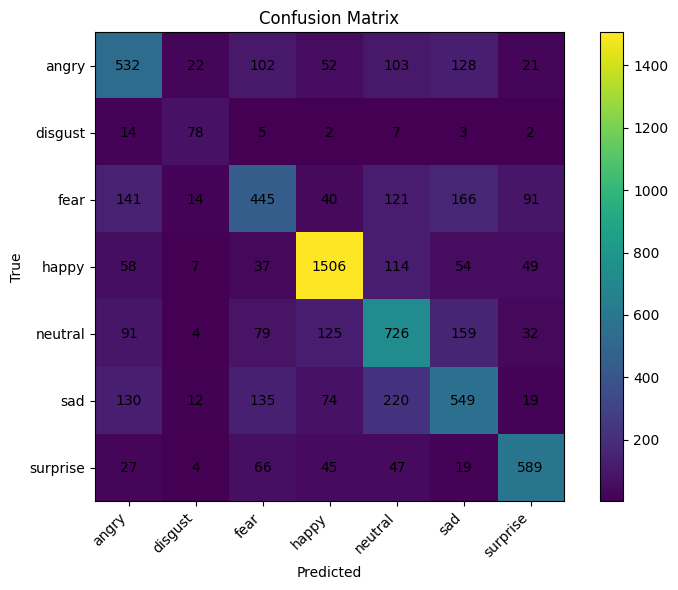

In [ ]:
validation_generator.reset()

pred_probs = best_model.predict(validation_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = validation_generator.classes

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## 11) Reliability: use an `uncertain` threshold

For deployment, do not force the model to always guess. If confidence is low, return `uncertain`.


In [ ]:
CONFIDENCE_THRESHOLD = 0.65

def predict_emotion_from_file(image_path, model=best_model, threshold=CONFIDENCE_THRESHOLD):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        color_mode="rgb"
    )
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)

    probs = model.predict(arr, verbose=0)[0]
    class_idx = int(np.argmax(probs))
    confidence = float(np.max(probs))
    emotion = class_names[class_idx]

    if confidence < threshold:
        emotion = "uncertain"

    return emotion, confidence, dict(zip(class_names, probs.round(4)))

# Example usage:
# emotion, confidence, all_probs = predict_emotion_from_file("/content/test_face.jpg")
# print(emotion, confidence)
# print(all_probs)


## 12) Save / download the best model

The best model file is saved in Colab as either:

- `best_resnet50v2_finetuned.keras`
- or `best_resnet50v2_stage1.keras`


In [ ]:
from google.colab import files

print("Best model path:", BEST_MODEL_PATH)
# Uncomment to download:
# files.download(BEST_MODEL_PATH)


Best model path: best_resnet50v2_finetuned.keras
